In [ ]:
#!/usr/bin/env python3

# ==============================
# IMPORTS
# ==============================

import torch                          # biblioteca principal do PyTorch
import torch.nn as nn                 # módulos de rede neural
import torch.optim as optim           # otimizadores
import numpy as np                    # operações numéricas
import sys

sys.path.append('/content/drive/MyDrive/alunos')

# importa funções obrigatórias do arquivo
from src.gtsrb import NUM_CLASSES, get_dataloaders, save_predictions




In [ ]:
from torchvision import transforms

#junta várias transformações em sequência

train_transform = transforms.Compose([
    #Redimensiona todas as imagens para 32x32 pixels
    transforms.Resize((32, 32)),

    #Inverte a imagem (espelha) No caso da placa não usei pois não faz sentido virar a placa
    #transforms.RandomHorizontalFlip( ),


    # DATA AUGMENTATION
    #Rotaciona aleatoriamente a imagem entre 15 levemente inclinada para esquerda levemente inclinada para direita
    transforms.RandomRotation(15),

    #Aplica uma transformação geométrica aleatória - não rotaciona e move a imagem até 10% na horizontal e vertical
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),

    #Aumenta e diminui o brilho e contranste em 20% aleatoriamente
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    #Converte a magem para um tensor (255, 128, 0) Depois: (1.0, 0.50, 0.0)
    transforms.ToTensor(),

    #Normaliza os canais RGB da imagem.
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    ),
])

In [ ]:
#Carrega os dados (Sem aplicar o transformer)
#carrega os dados já com split fixo (80% treino / 20% validação)
train_loader, val_loader, test_loader = get_dataloaders(
    img_size=32,     # tamanho da imagem (32x32)
    batch_size=128 #,   # tamanho do batch
    #train_transform=train_transform  # Aplicando data augmentation

)



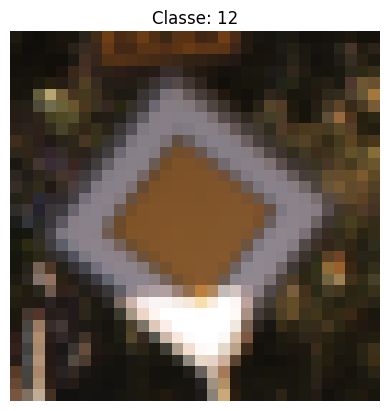

In [ ]:
###Verificando se o dataset foi carregado

import matplotlib.pyplot as plt

# pega um batch do treino
dataiter = iter(train_loader)
images, labels = next(dataiter)

# pega a primeira imagem do batch
img = images[0]

# desfaz a normalização
mean = [0.3403, 0.3121, 0.3214]
std = [0.2724, 0.2608, 0.2669]

for c in range(3):
    img[c] = img[c] * std[c] + mean[c]

# converte para formato (H, W, C)
img = img.permute(1, 2, 0)

# mostra imagem
plt.imshow(img)
plt.title(f"Classe: {labels[0].item()}")
plt.axis('off')
plt.show()

In [ ]:

# DEFINIÇÃO DA CNN (DO ZERO)


class Net(nn.Module):  # define a arquitetura da rede
    def __init__(self):
        super().__init__()

        # primeira camada convolucional: entrada 3 canais (RGB), saída 32 filtros
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        #self.bn1 = nn.BatchNorm2d(32)   # Adicionado BatchNormalization

        # camada de pooling (reduz dimensão)
        self.pool = nn.MaxPool2d(2, 2)



        # segunda camada convolucional
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        #self.bn2 = nn.BatchNorm2d(64)   # BatchNormalization


        # terceira camada convolucional
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        #self.bn3 = nn.BatchNorm2d(128)  # Batch Norm


        # camada totalmente conectada (entrada: 128 canais * 4 * 4)
        self.fc1 = nn.Linear(128 * 4 * 4, 128)

        # dropout para reduzir overfitting % dos neurônios serão desligados aleatoriamente
        #durante o treinamento:
        #Evita que a rede “dependa demais” de neurônios específicos.
        #reduz overfitting
        #CNN pequena	0.2 – 0.3
        #CNN média	0.3 – 0.5
        #Redes grandes 0.5 ou mais
        self.dropout = nn.Dropout(0.0)

        # segunda camada fully connected
        self.fc2 = nn.Linear(128, 64)

        # saída final com 43 classes
        self.fc3 = nn.Linear(64, NUM_CLASSES)

    def forward(self, x):  # define o fluxo de dados na rede

        # conv1 + ReLU + pooling → reduz 32x32 para 16x16
        x = self.pool(torch.relu(self.conv1(x)))
        # x = self.pool(torch.relu(self.bn1(self.conv1(x)))) Usando BN



        # conv2 + ReLU + pooling → reduz 16x16 para 8x8
        x = self.pool(torch.relu(self.conv2(x)))
        # x = self.pool(torch.relu(self.bn2(self.conv2(x)))) #Ysando BN

        # conv3 + ReLU + pooling → reduz 8x8 para 4x4
        x = self.pool(torch.relu(self.conv3(x)))
        #x = self.pool(torch.relu(self.bn3(self.conv3(x))))#Ysando BN

        # flatten (transforma tensor 2D em vetor)
        x = torch.flatten(x, 1)

        # camada fully connected + ativação
        x = torch.relu(self.fc1(x))

        # aplica dropout
        x = self.dropout(x)

        # outra camada fully connected
        x = torch.relu(self.fc2(x))

        # saída final (scores/logits)
        x = self.fc3(x)

        return x




In [ ]:
#CONFIGURAÇÃO DO TREINO


# define dispositivo (GPU se disponível, senão CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# instancia o modelo e envia para o dispositivo
model = Net().to(device)

# função de perda (classificação multiclasse)
criterion = nn.CrossEntropyLoss()

# otimizador (baseline: SGD)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Com Momentum
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

#Com Adam
#optimizer = optim.Adam(model.parameters(), lr=0.001)




In [ ]:
#TREINAMENTO

epochs = 100  # número total de épocas (quantas vezes o modelo verá todo o dataset)

# listas para armazenar métricas ao longo do treino (usadas no gráfico depois)
train_losses = []      # guarda a loss média de cada época
val_accuracies = []    # guarda a acurácia de validação de cada época

# loop principal de treinamento (uma iteração = uma época)
for epoch in range(epochs):

    #MODO TREINO


    model.train()  # ativa modo de treino (dropout e batchnorm funcionam corretamente)
    running_loss = 0.0  # acumulador da loss ao longo dos batches

    # percorre todos os batches do conjunto de treino
    for images, labels in train_loader:

        # envia os dados para GPU (se disponível) ou CPU
        images = images.to(device)
        labels = labels.to(device)

        # zera os gradientes acumulados da iteração anterior
        optimizer.zero_grad()

        # forward pass → modelo faz a predição
        outputs = model(images)

        # calcula a função de perda (erro entre previsão e rótulo real)
        loss = criterion(outputs, labels)

        # backward pass → calcula os gradientes (backpropagation)
        loss.backward()

        # atualiza os pesos da rede com base nos gradientes
        optimizer.step()

        # acumula o valor da loss do batch
        running_loss += loss.item()

    # calcula a média da loss da época inteira
    avg_loss = running_loss / len(train_loader)

    # salva a loss para análise futura (gráfico)
    train_losses.append(avg_loss)

    #VALIDAÇÃO


    model.eval()  # modo avaliação (desliga dropout e fixa batchnorm)

    correct = 0  # contador de acertos
    total = 0    # total de exemplos avaliados

    # desativa o cálculo de gradientes (mais rápido e economiza memória)
    with torch.no_grad():
        for images, labels in val_loader:

            # envia dados para dispositivo
            images = images.to(device)
            labels = labels.to(device)

            # forward pass (sem treino)
            outputs = model(images)

            # pega o índice da classe com maior score
            _, predicted = torch.max(outputs, 1)

            # atualiza total de exemplos
            total += labels.size(0)

            # soma quantos acertou
            correct += (predicted == labels).sum().item()

    # calcula a acurácia de validação
    val_acc = correct / total

    # salva para gráfico
    val_accuracies.append(val_acc)

    #PRINT DA ÉPOCA


    # mostra progresso do treinamento
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")



UnidentifiedImageError: Caught UnidentifiedImageError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataset.py", line 413, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/gtsrb.py", line 68, in __getitem__
    sample = PIL.Image.open(path).convert("RGB")
             ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist

In [ ]:
#GRÁFICO DE CONVERGÊNCIA


import matplotlib.pyplot as plt

plt.figure()  # cria nova figura

# plota a loss do treino
plt.plot(train_losses, label="Loss Treino")

# plota a acurácia de validação
plt.plot(val_accuracies, label="Val Acc")

# rótulos dos eixos
plt.xlabel("Épocas")
plt.ylabel("Valor")

# título do gráfico
plt.title("Convergência do Treinamento")

# legenda
plt.legend()

plt.savefig("grafico_convergencia.png")

# exibe o gráfico
plt.show()

(np.float64(-0.5), np.float64(273.5), np.float64(35.5), np.float64(-0.5))

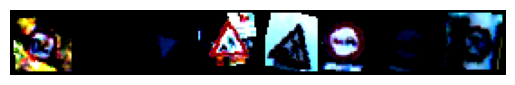

In [ ]:
#Dataaugmentation, exmplos

dataiter = iter(train_loader)
images, _ = next(dataiter)

import torchvision
import matplotlib.pyplot as plt

plt.imshow(torchvision.utils.make_grid(images[:8]).permute(1,2,0))
plt.axis('off')

In [ ]:
# ==============================
# MATRIZ DE CONFUSÃO (VALIDAÇÃO)
# ==============================

# cria matriz 43x43 (classes reais x preditas)
cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # pega predições
        _, predictions = torch.max(outputs, 1)

        # preenche matriz de confusão
        for label, pred in zip(labels, predictions):
            cm[label.item(), pred.item()] += 1




In [ ]:
import numpy as np

cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for l, p in zip(labels, preds):
            cm[l.item(), p.item()] += 1

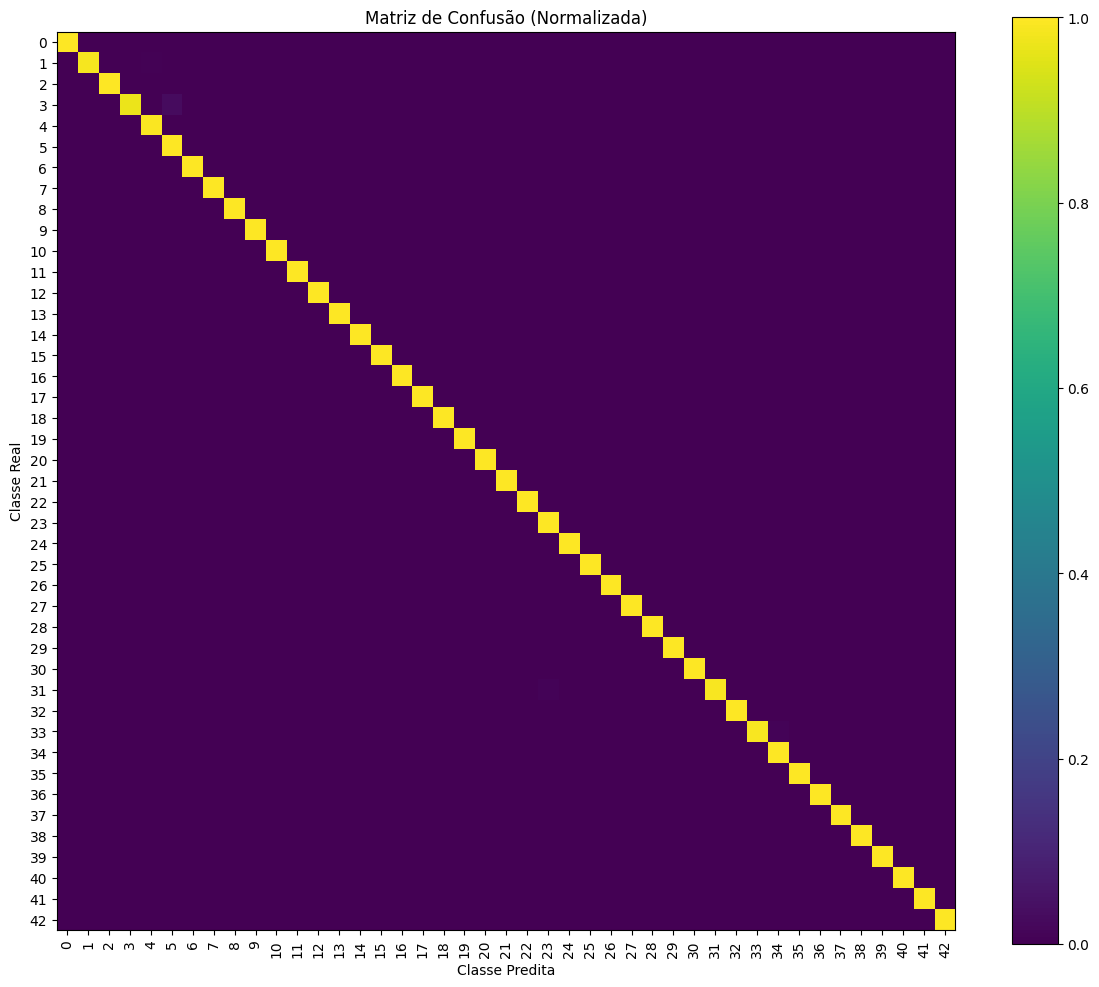

In [ ]:
import matplotlib.pyplot as plt

# normalizar por linha (acurácia por classe)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Matriz de Confusão (Normalizada)")
plt.colorbar()

# ticks (classes)
tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, tick_marks, rotation=90)
plt.yticks(tick_marks, tick_marks)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Matriz de Confusão (Normalizada)")
plt.colorbar()

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.tight_layout()

plt.savefig("matriz_confusao.pdf", bbox_inches='tight')
plt.close()

In [ ]:
# ==============================
# ACURÁCIA POR CLASSE
# ==============================

print("\nAcurácia por classe:")

for i in range(NUM_CLASSES):

    total_class = np.sum(cm[i, :])  # total de exemplos da classe

    if total_class == 0:
        acc = 0
    else:
        acc = cm[i, i] / total_class  # acertos / total

    print(f"Classe {i}: {acc:.4f}")





Acurácia por classe:
Classe 0: 1.0000
Classe 1: 0.9866
Classe 2: 1.0000
Classe 3: 0.9725
Classe 4: 0.9926
Classe 5: 1.0000
Classe 6: 1.0000
Classe 7: 1.0000
Classe 8: 1.0000
Classe 9: 1.0000
Classe 10: 1.0000
Classe 11: 1.0000
Classe 12: 1.0000
Classe 13: 1.0000
Classe 14: 1.0000
Classe 15: 1.0000
Classe 16: 1.0000
Classe 17: 1.0000
Classe 18: 1.0000
Classe 19: 1.0000
Classe 20: 1.0000
Classe 21: 1.0000
Classe 22: 1.0000
Classe 23: 1.0000
Classe 24: 1.0000
Classe 25: 1.0000
Classe 26: 1.0000
Classe 27: 1.0000
Classe 28: 1.0000
Classe 29: 1.0000
Classe 30: 1.0000
Classe 31: 0.9908
Classe 32: 1.0000
Classe 33: 0.9896
Classe 34: 1.0000
Classe 35: 1.0000
Classe 36: 1.0000
Classe 37: 1.0000
Classe 38: 1.0000
Classe 39: 1.0000
Classe 40: 1.0000
Classe 41: 1.0000
Classe 42: 1.0000


In [ ]:
# ==============================
# TESTE FINAL + EXPORTAÇÃO CSV
# ==============================

model.eval()

all_preds = []

with torch.no_grad():
    for images, _ in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu()

        all_preds.append(preds)

# concatena todas as predições
y_pred = torch.cat(all_preds)

# salva CSV no formato exigido
save_predictions(
    y_pred,
    "results/predicoes_baseline.csv",
    experiment_name="Baseline CNN SGD+momentum"
)

print(f"\nPredições salvas ({len(y_pred)} imagens)")


Predições salvas (12630 imagens)
